## Modeling
Since we are doing multiclass classification, we want to first build a baseline logistic regression model. 
This is the right baseline as it is simple, interpretable and fast to train. This will be our comparison point - if XGBoost only beats it by 1%, that's a meaninglful finding. If it beats by 20%, that justifies the added complexity

In [70]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split #for train/test split
from sklearn.linear_model import LogisticRegression #for Logistic Reg

In [71]:
df = pd.read_csv("../data/processed/features_labeled.csv", low_memory=False)   

In [72]:
df.shape

(333984, 39)

Logistic regression uses gradient descent to optimize weights, so features on different scales cause uneven gradient    
  steps and slow/poor convergence. Tree models split on thresholds so scale is irrelevant.

In [73]:
df.columns

Index(['product_name', 'categories', 'countries', 'nutriscore_score',
       'nutriscore_grade', 'fat_100g', 'saturated-fat_100g',
       'carbohydrates_100g', 'sugars_100g', 'fiber_100g', 'proteins_100g',
       'sodium_100g', 'health_label', 'log_fat_100g', 'log_saturated-fat_100g',
       'log_carbohydrates_100g', 'log_sugars_100g', 'log_fiber_100g',
       'log_proteins_100g', 'log_sodium_100g', 'calories_100g',
       'protein_calorie_ratio', 'fiber_carb_ratio', 'category_top',
       'cat_Beverages', 'cat_Condiments', 'cat_Dairies', 'cat_Desserts',
       'cat_Entrees', 'cat_Frozen foods', 'cat_Meals',
       'cat_Meats and their products', 'cat_Other',
       'cat_Plant-based foods and beverages', 'cat_Salted snacks',
       'cat_Sandwiches', 'cat_Seafood', 'cat_Snacks',
       'cat_Toppings & Ingredients'],
      dtype='object')

Target - health_label: we will predict this

product_name, countries, categories, category_top — these are metadata/text columns, not numeric features 

nutriscore_grade, nutriscore_score — these are the source of label, including them would be data leakage.

I will exclude nutriscore_grade and nutriscore_score from features because they're the source of the label — including them 
  would be data leakage. The model needs to predict health from nutrients alone, not from the score it was derived from.

Feature columns - 
  - The 7 original nutrient columns                                                                                                               
  - The 7 log-transformed columns                                                                                                               
  - calories_100g, protein_calorie_ratio, fiber_carb_ratio
  - The 15 one-hot category columns (cat_*) 

In [74]:
X = df.drop(['product_name', 'categories', 'countries', 'nutriscore_score',
       'nutriscore_grade','category_top','health_label'], axis=1)

In [75]:
y = df['health_label']

In [76]:
X.shape

(333984, 32)

In [77]:
y.value_counts()

health_label
Unhealthy    189826
Healthy       83858
Moderate      60300
Name: count, dtype: int64

In [78]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.20, random_state = 42)

In [79]:
print(X_train.shape,X_test.shape)

(267187, 32) (66797, 32)


Now we need to handle two things before training:

  1. Missing values — logistic regression can't accept NaNs
    We will be following the standard approach of imputation - filling nulls with median of each column. Since our nutrient columns are right skewed with outliers, median is a safer choice than mean.
  2. Feature scaling — we'll use StandardScaler — it subtracts the mean and divides by standard deviation, putting all features on the same scale.
    Logistic regression uses gradient descent to find optimal weights. If calories  
  range 0–1700 and fiber ranges 0–5, the gradient steps are vastly different sizes, making it hard to converge. Scaling puts everything on the    
  same 0–1 or -1–1 range so all features are treated equally.


Both imputation and scaling need to be fit on training data only, then applied to both train and test.
We must fit the scaler on training data only, not the full dataset - If you fit the scaler on the full dataset, the test set's mean and standard deviation leak into the training process — the model has indirectly "seen" the test data. In production, you'll only have training statistics available, so that's what you simulate.

I fit the scaler on training data only and transformed the test set using training statistics — fitting on the full     
  dataset would leak test set information into training, giving an overly optimistic evaluation.

In [80]:
  from sklearn.pipeline import Pipeline   
  from sklearn.impute import SimpleImputer                                                                                                        
  from sklearn.preprocessing import StandardScaler

I used a sklearn Pipeline to chain imputation, scaling, and the model — this prevents data leakage by ensuring all      
  preprocessing is fit on training data only, and makes the whole workflow reproducible and deployable as a single object.

In [81]:
pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaling', StandardScaler()),
    ('model', LogisticRegression(class_weight='balanced', max_iter=1000))
])

The Pipeline takes a list of tuples — each tuple is ('name', object):

  'imputer' — SimpleImputer(strategy='median') fills NaN values with the median of each column. Fit on training data, so test set uses training medians.

  'scaling' — StandardScaler() subtracts the mean and divides by standard deviation, putting all features on the same scale. Again fit on training data only.

  'model' — LogisticRegression(class_weight='balanced', max_iter=1000):
  - class_weight='balanced' — automatically gives more weight to minority classes (Healthy, Moderate) to counteract the imbalance
  - max_iter=1000 — gives the optimizer more iterations to converge on a large dataset

In [82]:
pipeline.fit(X_train, y_train)

Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('scaling', StandardScaler()),
                ('model',
                 LogisticRegression(class_weight='balanced', max_iter=1000))])

In [83]:
from sklearn.metrics import classification_report

y_pred = pipeline.predict(X_test)
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

     Healthy       0.81      0.84      0.82     16656
    Moderate       0.57      0.75      0.65     12245
   Unhealthy       0.97      0.86      0.91     37896

    accuracy                           0.83     66797
   macro avg       0.78      0.81      0.79     66797
weighted avg       0.86      0.83      0.84     66797



  Precision — "when I say Healthy, how often am I right?"                                                                                                                       
  - Of all foods the model predicted as Healthy, 81% actually were Healthy. The other 19% were wrongly labeled Healthy.                                                         
                                                                                                                       
  Recall — "of all actual Healthy foods, how many did I catch?"                                                                                                                 
  - Of all foods that actually are Healthy, the model found 84% of them. It missed 16%.                                                                                         
                                                                                                                                                                                
  ---                                                                                                                                                                           
  Memory trick:                                                                                                                                                                 
                                                                                                                                                                                
  - Precision = don't cry wolf. When you make a claim, be right.                                                                                                                
  - Recall = don't miss anything. Find everything that's there.  

  If you predict Unhealthy for a food that's actually Healthy — the user avoids a good food. Annoying but harmless.                                                             
                                                                                                                                                                                
  If you predict Healthy for a food that's actually Unhealthy — the user eats something bad thinking it's fine. Worse.
                                          
  So for this app, precision on Unhealthy matters most. Look at the report — it's 0.97. That's excellent. 

I prioritized precision on the Unhealthy class — a false Healthy prediction is worse than a false Unhealthy prediction for a health app. At 0.97      
  precision, the baseline logistic regression performs well on the most critical metric.

Each tree corrects the errors of the previous one, which makes it powerful on complex, non-linear relationships.                             
                                                                                                                                                                                
  For this dataset specifically, XGBoost might do better because:                                                                                                               
  - Nutrient relationships with health labels may not be linear                                                                                                                 
  - XGBoost handles missing values natively — no imputation needed                                                                                                              
  - It's generally more powerful on tabular data                  
                                                                                                                                                                                
  This is interviewable. "I chose XGBoost over logistic regression as my final model because nutrient-to-health relationships are likely non-linear, and XGBoost consistently   
  outperforms linear models on tabular data. I used logistic regression as a baseline to quantify the improvement."  

In [84]:
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder ##we need label encoder because xgboost expects numeric lables and not strigs like "healthy"

In [85]:
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train) #first fit learns mapping from training labels, healthy=0, moderate=1, unhealthy=2, then transform applies that mapping, converting strings to integers
y_test_enc = le.transform(y_test) #applies the same mapping learned from training to the test labels, we do not fit again, we use training's mapping so both sets are identical

In [86]:
import numpy as np
np.unique(y_train_enc)

array([0, 1, 2])

In [92]:
pipeline_2 = Pipeline([
    ('scaler', StandardScaler()),
    ('model', XGBClassifier(eval_metric='mlogloss', random_state=42))
])

In [93]:
pipeline_2.fit(X_train, y_train_enc)

Pipeline(steps=[('scaler', StandardScaler()),
                ('model',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None, colsample_bynode=None,
                               colsample_bytree=None, device=None,
                               early_stopping_rounds=None,
                               enable_categorical=False, eval_metric='mlogloss',
                               feature_types=None, gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=None,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=None, n_jobs=None,
                               num_parallel_tree=None,
                               objective='multi:softprob', ...))])

In [95]:
y_pred_xgb = pipeline_2.predict(X_test)
print(classification_report(y_test_enc, y_pred_xgb, target_names = le.classes_))

              precision    recall  f1-score   support

     Healthy       0.92      0.94      0.93     16656
    Moderate       0.88      0.85      0.87     12245
   Unhealthy       0.98      0.98      0.98     37896

    accuracy                           0.95     66797
   macro avg       0.93      0.92      0.93     66797
weighted avg       0.95      0.95      0.95     66797



The biggest jump is Moderate — from 0.65 to 0.87. That's the hardest class, and XGBoost handles the non-linear boundary between Moderate and its neighbors much better than logistic regression.                                                                                                                                                          
   
XGBoost improved overall accuracy from 83% to 95%, with the largest gain on the Moderate class — from 0.65 to 0.87 F1. This confirms that nutrient-to-health relationships are non-linear, justifying the added model complexity.

XGBoost is a gradient boosting algorithm — it builds trees sequentially, each correcting the residual errors of the previous ensemble. It outperforms
  linear models when feature-label relationships are non-linear, which is the case with nutrient data.

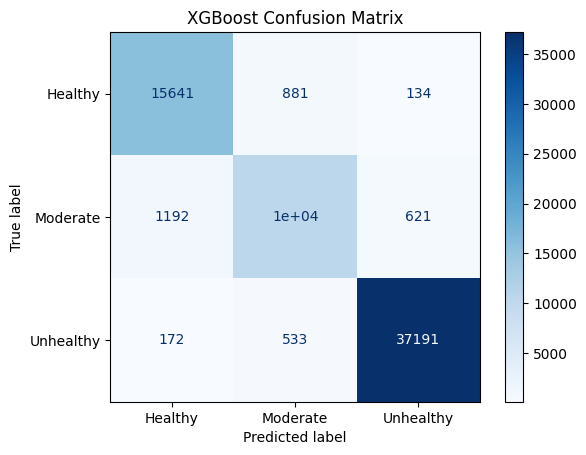

In [98]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test_enc, y_pred_xgb)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap='Blues')
plt.title('XGBoost Confusion Matrix')
plt.show()

  Rows = actual labels. Columns = predicted labels.                                                                                               
                                                                                                                                                  
  So each cell tells you: "of all foods that were actually X, how many did the model predict as Y?"                                               
                                          
  - Diagonal cells (top-left to bottom-right) — correct predictions                                                                               
  - Off-diagonal cells — mistakes  

The confusion matrix showed the model's main weakness was confusing Moderate with Healthy — 1,192 misclassifications(10000 correct Moderate predictions).   
  This is expected since C-grade foods are nutritionally adjacent to B-grade foods. For a health app, this is an acceptable error — predicting a  
  Moderate food as Healthy is less harmful than predicting Unhealthy as Healthy.

Next we use joblib to save our model. joblib serializes Python objects to disk — it converts the pipeline object (which lives in memory) into a file you can reload later without retraining. 

In [99]:
import joblib

joblib.dump(pipeline_2, '../models/model.joblib')
joblib.dump(le,'../models/label_encoder.joblib')

#to load later - 
#pipeline_2 = joblib.load('../models/model.joblib')

['../models/label_encoder.joblib']

I serialized the full pipeline with joblib — not just the model, but the entire preprocessing pipeline. This means in   
  production I just call pipeline.predict() on raw input and get a prediction, with no separate preprocessing step.

In [100]:
import joblib
joblib.dump(X.columns.tolist(), '../models/feature_names.joblib')


['../models/feature_names.joblib']